IMPORT LIBRARY

In [2]:
!pip install shap


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

# model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# evaluasi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# SHAP
import shap

import matplotlib.pyplot as plt

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOAD DATASET

In [4]:
df = pd.read_csv('dataset/url_features_extracted1.csv')

# lihat data
print(df.head())
print(df.info())

                                               URL  url_length  \
0  https://keraekken-loagginnusa.godaddysites.com/          47   
1         https://metamsk01lgiix.godaddysites.com/          40   
2                          http://myglobaltech.in/          23   
3                   http://djtool-for-spotify.com/          30   
4  https://scearmcoommunnlty.com/invent/freind/get          47   

   has_ip_address  dot_count  https_flag  url_entropy  token_count  \
0               0          2           1     4.250669            6   
1               0          2           1     4.196439            6   
2               0          1           0     3.936180            5   
3               0          1           0     3.894740            5   
4               0          1           1     4.143127            7   

   subdomain_count  query_param_count  tld_length  path_length  \
0                1                  1           3            1   
1                1                  1           3 

PRA-PREPROCESSING

In [5]:
X = df.drop(['URL', 'ClassLabel'], axis=1)
y = df['ClassLabel']

In [6]:
print(df.isnull().sum())

URL                          0
url_length                   0
has_ip_address               0
dot_count                    0
https_flag                   0
url_entropy                  0
token_count                  0
subdomain_count              0
query_param_count            0
tld_length                   0
path_length                  0
has_hyphen_in_domain         0
number_of_digits             0
tld_popularity               0
suspicious_file_extension    0
domain_name_length           0
percentage_numeric_chars     0
ClassLabel                   1
dtype: int64


In [7]:
print(df['ClassLabel'].head(20))

0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    0.0
16    0.0
17    0.0
18    0.0
19    0.0
Name: ClassLabel, dtype: float64


In [8]:
print(df['ClassLabel'].isna().sum())
print(df['ClassLabel'].unique())

1
[ 0.  1. nan]


In [9]:
print(X.isna().sum())

url_length                   0
has_ip_address               0
dot_count                    0
https_flag                   0
url_entropy                  0
token_count                  0
subdomain_count              0
query_param_count            0
tld_length                   0
path_length                  0
has_hyphen_in_domain         0
number_of_digits             0
tld_popularity               0
suspicious_file_extension    0
domain_name_length           0
percentage_numeric_chars     0
dtype: int64


In [10]:
print(df['ClassLabel'].unique())

[ 0.  1. nan]


In [11]:
df = df.dropna(subset=['ClassLabel'])

In [12]:
print("NaN di df:", df['ClassLabel'].isna().sum())
print("Unique:", df['ClassLabel'].unique())

NaN di df: 0
Unique: [0. 1.]


SPLIT DATA

In [1]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

KeyboardInterrupt: 

In [14]:
print("NaN di y_train:", y_train.isna().sum())

NaN di y_train: 1


In [15]:
print("NaN di X_train:", X_train.isna().sum().sum())
print("NaN di y_train:", y_train.isna().sum())

NaN di X_train: 0
NaN di y_train: 1


In [16]:
df = df.reset_index(drop=True)

In [17]:
X = df.drop(['URL', 'ClassLabel'], axis=1)
y = df['ClassLabel']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

TRAIN MODEL

In [19]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Random Forest (MODEL UTAMA)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,0]  # karena phishing = 0

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, pos_label=0))
    print("Recall:", recall_score(y_test, y_pred, pos_label=0))
    print("F1 Score:", f1_score(y_test, y_pred, pos_label=0))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [21]:
print("=== Decision Tree ===")
evaluate_model(dt, X_test, y_test)

print("\n=== Logistic Regression ===")
evaluate_model(lr, X_test, y_test)

print("\n=== Random Forest ===")
evaluate_model(rf, X_test, y_test)

=== Decision Tree ===


Accuracy: 0.9990614503062636
Precision: 0.999372352110466
Recall: 0.999137187230371
F1 Score: 0.9992547558344773
Confusion Matrix:
 [[12738    11]
 [    8  7487]]

=== Logistic Regression ===
Accuracy: 0.9960482118158467
Precision: 0.9981127624439726
Recall: 0.9956074986273433
F1 Score: 0.9968585565067148
Confusion Matrix:
 [[12693    56]
 [   24  7471]]

=== Random Forest ===
Accuracy: 0.9995554238292828
Precision: 0.9993728441517717
Recall: 0.9999215624754882
F1 Score: 0.9996471280141149
Confusion Matrix:
 [[12748     1]
 [    8  7487]]


In [22]:
print(y_test.head())

64156    1.0
22321    0.0
12633    0.0
62138    0.0
65467    1.0
Name: ClassLabel, dtype: float64


In [23]:
import pandas as pd

hasil = pd.DataFrame({
    'Actual': y_test,
    'Predicted': rf.predict(X_test)
})

print(hasil.head(20))

       Actual  Predicted
64156     1.0        1.0
22321     0.0        0.0
12633     0.0        0.0
62138     0.0        0.0
65467     1.0        1.0
24145     0.0        0.0
2605      0.0        0.0
13839     0.0        0.0
66594     1.0        1.0
33150     0.0        0.0
95684     1.0        1.0
12309     0.0        0.0
71231     1.0        1.0
48151     0.0        0.0
30076     0.0        0.0
77489     1.0        1.0
98265     1.0        1.0
61153     0.0        0.0
35494     0.0        0.0
67618     1.0        1.0


In [24]:
# Decision Tree
y_prob_dt = dt.predict_proba(X_test)[:,0]
print("ROC DT:", roc_auc_score(y_test == 0, y_prob_dt))

# Logistic Regression
y_prob_lr = lr.predict_proba(X_test)[:,0]
print("ROC LR:", roc_auc_score(y_test == 0, y_prob_lr))

# Random Forest
y_prob_rf = rf.predict_proba(X_test)[:,0]
print("ROC RF:", roc_auc_score(y_test == 0, y_prob_rf))

ROC DT: 0.9990349044891015
ROC LR: 0.9994896903842241
ROC RF: 0.9999966458670306


In [25]:
y_prob_rf = rf.predict_proba(X_test)[:,0]  # phishing
risk_score = y_prob_rf * 100

In [26]:
import pandas as pd

hasil = pd.DataFrame({
    'Actual': y_test,
    'Prediksi': rf.predict(X_test),
    'Probabilitas Phishing': y_prob_rf,
    'Risk Score (%)': risk_score
})

print(hasil.head())

       Actual  Prediksi  Probabilitas Phishing  Risk Score (%)
64156     1.0       1.0                    0.0             0.0
22321     0.0       0.0                    1.0           100.0
12633     0.0       0.0                    1.0           100.0
62138     0.0       0.0                    1.0           100.0
65467     1.0       1.0                    0.0             0.0


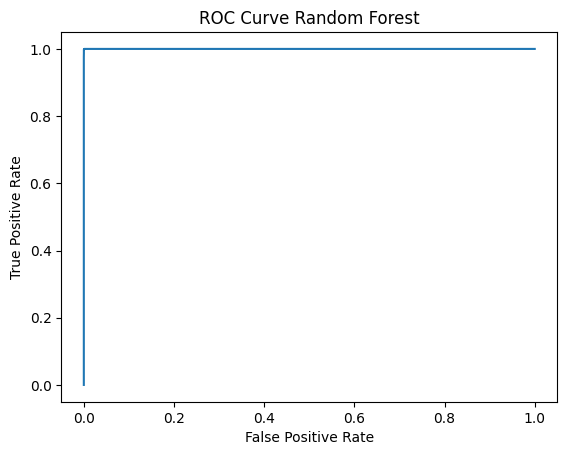

In [27]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_rf, pos_label=0)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Random Forest")
plt.show()

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[0], X_test)

In [29]:
prob_phishing = rf.predict_proba(X_test)[:,0]    # class 0 = phishing
prob_legitimate = rf.predict_proba(X_test)[:,1]   # class 1 = legitimate

In [30]:
import pandas as pd

hasil = pd.DataFrame({
    'Actual': y_test,
    'Prediksi': rf.predict(X_test),
    'Prob_Phishing': prob_phishing,
    'Prob_Legitimate': prob_legitimate
})

print(hasil.head(10))

       Actual  Prediksi  Prob_Phishing  Prob_Legitimate
64156     1.0       1.0            0.0              1.0
22321     0.0       0.0            1.0              0.0
12633     0.0       0.0            1.0              0.0
62138     0.0       0.0            1.0              0.0
65467     1.0       1.0            0.0              1.0
24145     0.0       0.0            1.0              0.0
2605      0.0       0.0            1.0              0.0
13839     0.0       0.0            1.0              0.0
66594     1.0       1.0            0.0              1.0
33150     0.0       0.0            1.0              0.0


In [31]:
import numpy as np

print(np.unique(prob_phishing))

[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.14 0.15
 0.16 0.18 0.19 0.21 0.22 0.23 0.28 0.29 0.33 0.36 0.42 0.44 0.51 0.53
 0.56 0.57 0.59 0.63 0.68 0.69 0.7  0.76 0.77 0.78 0.79 0.8  0.81 0.82
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99 1.  ]


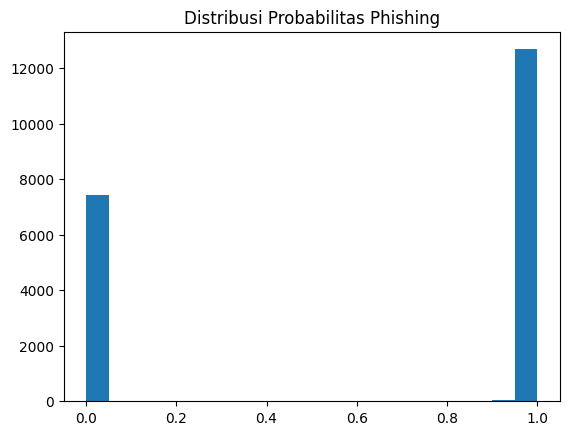

In [32]:
import matplotlib.pyplot as plt

plt.hist(prob_phishing, bins=20)
plt.title("Distribusi Probabilitas Phishing")
plt.show()

In [33]:
import shap

# buat explainer
explainer = shap.TreeExplainer(rf)

# hitung shap values
shap_values = explainer.shap_values(X_test)

In [35]:
shap_values = explainer(X_test)

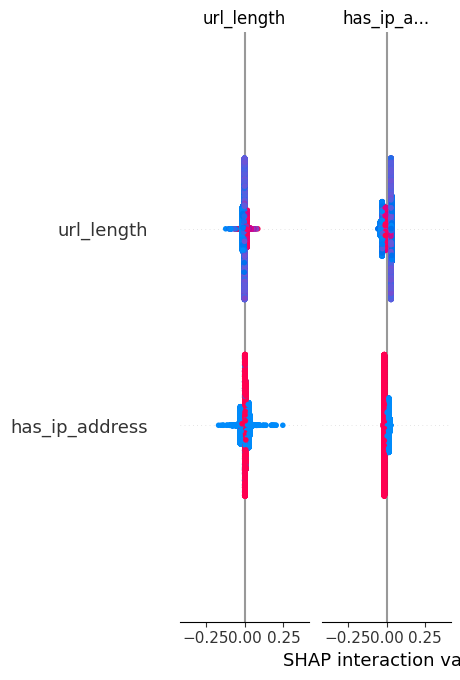

In [36]:
shap.summary_plot(shap_values, X_test)

In [37]:
i = 0  # index data

shap.force_plot(
    explainer.expected_value[0],
    shap_values[0][i],
    X_test.iloc[i]
)

ValueError: visualize() can only display Explanation objects (or arrays of them)!

In [38]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

i = 0  # data ke-0

shap.plots.force(shap_values[i])

TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).